In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def residual_block(x, filters, kernel_size=3, stride=1, downsample=False):
    shortcut = x
    
    if downsample:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Add()([x, shortcut])  
    x = layers.ReLU()(x)
    
    return x

def build_resnet(input_shape=(224, 224, 3), num_classes=1000, num_blocks=[2, 2, 2, 2]):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
    
    filters = 64
    for i, blocks in enumerate(num_blocks):
        for j in range(blocks):
            if j == 0 and i > 0:
                x = residual_block(x, filters * 2, stride=2, downsample=True)
                filters *= 2  
            else:
                x = residual_block(x, filters)
    
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

# Example usage
resnet = build_resnet(input_shape=(224, 224, 3),
            num_classes=1000, num_blocks=[3, 4, 6, 3])  # ResNet-34

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

train_dir = r"C:/Users/Admin/Desktop/my_ai_book/data/datasets/cat-and-dog/training_set"
test_dir  = r"C:/Users/Admin/Desktop/my_ai_book/data/datasets/cat-and-dog/test_set"

IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 1
AUTOTUNE = tf.data.AUTOTUNE

# Nếu thư mục là cats/dogs đúng chuẩn thì không cần class_names
# Ở đây ép cho chắc chắn theo tên thư mục phổ biến
CLASS_NAMES = ["cats", "dogs"] #Cats: 0, dogs: 1

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="binary",
    shuffle=True,
    seed=SEED,
    class_names=CLASS_NAMES
)
# lấy 20% train làm validation
val_size = int(0.2 * len(train_ds))
val_ds   = train_ds.take(val_size)
train_ds = train_ds.skip(val_size)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="binary", # dựa trên vị trí của thư mục nhãn (class)
    shuffle=False,
    class_names=CLASS_NAMES
)

def configure(ds, training=False):
    if training:
        ds = ds.shuffle(1000, seed=SEED, reshuffle_each_iteration=True)
    return ds.prefetch(AUTOTUNE)

train_ds = configure(train_ds, training=True)
val_ds   = configure(val_ds)
test_ds  = configure(test_ds)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [4]:
# Lấy 1 batch đầu tiên từ train_ds
images, labels = next(iter(train_ds))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)


Image batch shape : (32, 224, 224, 3)
Label batch shape : (32, 1)


In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def residual_block(x, filters, kernel_size=3, stride=1, downsample=False):
    shortcut = x
    
    if downsample:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    x = layers.Conv2D(filters, kernel_size=kernel_size, strides=1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    
    x = layers.Add()([x, shortcut])  
    x = layers.ReLU()(x)
    
    return x

def build_resnet(input_shape=(224, 224, 3), num_classes=1000, num_blocks=[2, 2, 2, 2]):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
    
    filters = 64
    for i, blocks in enumerate(num_blocks):
        for j in range(blocks):
            if j == 0 and i > 0:
                x = residual_block(x, filters * 2, stride=2, downsample=True)
                filters *= 2  
            else:
                x = residual_block(x, filters)
    
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    return model

# Example usage
resnet = build_resnet(input_shape=(224, 224, 3),
            num_classes=1, num_blocks=[3, 4, 6, 3])  # ResNet-34


In [6]:
resnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [7]:
history = resnet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
201/201 [==============================] - 55s 198ms/step - loss: 0.6664 - accuracy: 0.6097 - val_loss: 0.8930 - val_accuracy: 0.5431
Epoch 2/20
201/201 [==============================] - 41s 191ms/step - loss: 0.5558 - accuracy: 0.7079 - val_loss: 0.5819 - val_accuracy: 0.6806
Epoch 3/20
201/201 [==============================] - 41s 192ms/step - loss: 0.4697 - accuracy: 0.7769 - val_loss: 0.5063 - val_accuracy: 0.7625
Epoch 4/20
201/201 [==============================] - 41s 192ms/step - loss: 0.3989 - accuracy: 0.8164 - val_loss: 0.5968 - val_accuracy: 0.7131
Epoch 5/20
201/201 [==============================] - 41s 192ms/step - loss: 0.3047 - accuracy: 0.8726 - val_loss: 0.5720 - val_accuracy: 0.7638
Epoch 6/20
201/201 [==============================] - 41s 194ms/step - loss: 0.2388 - accuracy: 0.9021 - val_loss: 0.8118 - val_accuracy: 0.7219
Epoch 7/20
201/201 [==============================] - 43s 201ms/step - loss: 0.1732 - accuracy: 0.9308 - val_loss: 1.0773 - val_ac

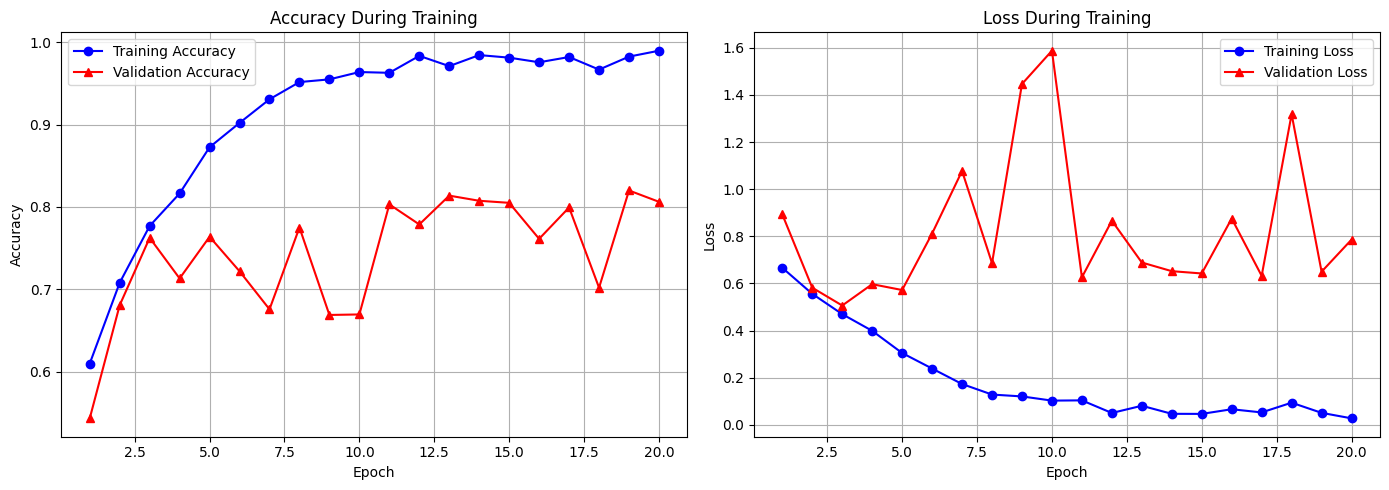

In [8]:
import matplotlib.pyplot as plt

# Lấy dữ liệu training từ lịch sử
acc      = history.history["accuracy"]
val_acc  = history.history["val_accuracy"]
loss     = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "bo-", label="Training Accuracy")
plt.plot(epochs, val_acc, "r^-", label="Validation Accuracy")
plt.title("Accuracy During Training")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "bo-", label="Training Loss")
plt.plot(epochs, val_loss, "r^-", label="Validation Loss")
plt.title("Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
y_pred_prob = resnet.predict(test_ds)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

64/64 [==============================] - 4s 54ms/step


In [10]:
import numpy as np

# Lấy toàn bộ labels từ test_ds
y_test_list = []

for _, labels in test_ds:
    y_test_list.append(labels.numpy())

y_test = np.concatenate(y_test_list).flatten()


In [11]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Cat", "Dog"]))


Confusion Matrix:
 [[618 393]
 [114 898]]

Classification Report:
               precision    recall  f1-score   support

         Cat       0.84      0.61      0.71      1011
         Dog       0.70      0.89      0.78      1012

    accuracy                           0.75      2023
   macro avg       0.77      0.75      0.74      2023
weighted avg       0.77      0.75      0.74      2023



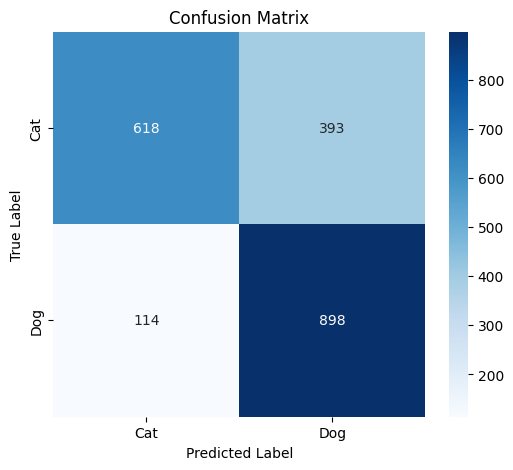

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()